In [1]:
# I need to load the dataset
# What function did we use?
# import data 
import pandas as pd 
# Arrays, vectors, math
import numpy as np
# Regular expressions / text cleaning
import re
# count labels tools we need is Counter 
from collections import Counter
# fetch_20newsgroups import dataset
from sklearn.datasets import fetch_20newsgroups
# data need to split 
from sklearn.model_selection import train_test_split
# data to to be modeled
from sklearn.linear_model import LogisticRegression
# evaluation and matric
from sklearn.metrics import accuracy_score, classification_report
# feature_extraction
from sklearn.feature_extraction.text import TfidfVectorizer
# Load GloVe tools gensim 

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [2]:
df_review = pd.read_csv('/home/susan/Natural_Language_Processing/data/imdb_reviews.tsv', sep='\t')
print(df_review.columns)
print(df_review[['review','pos','ds_part']].head())


Index(['tconst', 'title_type', 'primary_title', 'original_title', 'start_year',
       'end_year', 'runtime_minutes', 'is_adult', 'genres', 'average_rating',
       'votes', 'review', 'rating', 'sp', 'pos', 'ds_part', 'idx'],
      dtype='str')
                                              review  pos ds_part
0  The pakage implies that Warren Beatty and Gold...    0   train
1  How the hell did they get this made?! Presenti...    0   train
2  There is no real story the film seems more lik...    0    test
3  Um .... a serious film about troubled teens in...    1    test
4  I'm totally agree with GarryJohal from Singapo...    1    test


In [3]:
# 1. Select the needed columns
df_text = df_review[['review', 'pos', 'ds_part']].copy()

# check the data 
print(df_text.shape)
# check missing and duplicated data
print("missing_data:\n",df_text.isna().sum())
print("duplicated_data:\n",df_text.duplicated(subset=['review']).sum())
print(df_text['pos'].value_counts())
print(df_text['ds_part'].value_counts())



(47331, 3)
missing_data:
 review     0
pos        0
ds_part    0
dtype: int64
duplicated_data:
 91
pos
0    23715
1    23616
Name: count, dtype: int64
ds_part
train    23796
test     23535
Name: count, dtype: int64


In [4]:
# lowercase the reviews and normalize extra whitespace.
def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()

    # Replace repeated whitespace with one space
    text = re.sub(r'\s+', ' ', text)

    # Remove spaces at the beginning and end
    text = text.strip()

    return text

clean_reviews = []

for review in df_text['review']:
    cleaned_review = preprocess_text(review)
    clean_reviews.append(cleaned_review)

df_text['review_clean'] = clean_reviews


In [5]:
# display duplicated row 
# Display up to five rows with duplicate cleaned reviews
# Display up to five rows with duplicate cleaned reviews
duplicates = df_text.duplicated(subset=["review_clean"], keep="first")

print(duplicates.head(5))
print("Duplicate rows:", duplicates.sum())

0    False
1    False
2    False
3    False
4    False
dtype: bool
Duplicate rows: 93


In [6]:
# Remove duplicate cleaned reviews and keep the first occurrence
df_text = df_text.drop_duplicates(
    subset=['review_clean'],
    keep='first'
).copy()
df_text.duplicated(subset=['review_clean']).sum()

np.int64(0)

pos
0    50.127016
1    49.872984
Name: proportion, dtype: float64


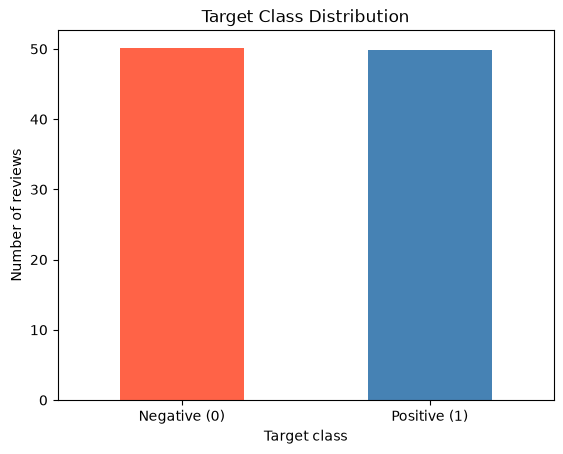

In [7]:
# preprocess for modeling:
# Examine the traget distribution 
# Count  class percentatage
class_counts =class_percentages = (
    df_text['pos']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100))
print(class_percentages)

# visualization the distribution
import matplotlib.pyplot as plt

class_counts.plot(
    kind='bar',
    color=['tomato', 'steelblue']
)

plt.title('Target Class Distribution')
plt.xlabel('Target class')
plt.ylabel('Number of reviews')
plt.xticks(
    ticks=[0, 1],
    labels=['Negative (0)', 'Positive (1)'],
    rotation=0
)
plt.show()

he target distribution is approximately balanced, with 50.13% negative reviews and 49.87% positive reviews. Therefore, no class-balancing techniques, such as oversampling, undersampling, or class weights, are necessary.

In [8]:
## nltk
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')



[nltk_data] Downloading package punkt to /home/susan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/susan/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /home/susan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/susan/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [9]:
# Create the function:
lemmatizer = WordNetLemmatizer()

def preprocess_text_nltk(text):
    # Convert to lowercase
    text = str(text).lower()

    # Keep letters and spaces
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Lemmatize
    clean_tokens = []

    for token in tokens:
        lemma = lemmatizer.lemmatize(token)
        clean_tokens.append(lemma)

    # Convert tokens back into one string
    return ' '.join(clean_tokens)
review_clean_nltk = []
# Apply it using a for loop
for review in df_text['review']:
    cleaned_review = preprocess_text_nltk(review)
    review_clean_nltk.append(cleaned_review)

df_text['review_clean_nltk'] = review_clean_nltk

In [10]:
# Check the result
df_text[
    ['review', 'review_clean_nltk']
].head()

,review,review_clean_nltk
0,The pakage implies that Warren Beatty and Gold...,the pakage implies that warren beatty and gold...
1,How the hell did they get this made?! Presenti...,how the hell did they get this made presenting...
2,There is no real story the film seems more lik...,there is no real story the film seems more lik...
3,Um .... a serious film about troubled teens in...,um a serious film about troubled teen in singa...
4,I'm totally agree with GarryJohal from Singapo...,i m totally agree with garryjohal from singapo...


In [11]:
# Data split
from sklearn.model_selection import train_test_split
# Separate the predefined train and test sets
train = df_text[df_text['ds_part'] == 'train'].copy()
test = df_text[df_text['ds_part'] == 'test'].copy()

# Features and targets
X_train = train['review_clean_nltk']
y_train = train['pos']

X_test = test['review_clean_nltk']
y_test = test['pos']
# Step 3 — Convert NLTK text using TF-IDF:
# Convert text into numbers using TF-IDF:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

---
Training text → fit_transform()

Test text → transform()

---

In [12]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (23756, 64194)
Test TF-IDF shape: (23482, 64194)


#### Train at least three different models for the given train dataset.
pos is 0 or 1, this is a classification problem.
* Therefore,we do not use LinearRegression; it is intended for continuous numerical targets.
* A good set of three models for text classification is:

        Dummy classifier — baseline
        Logistic regression — strong linear model for TF-IDF
        Random forest classifier — tree-based comparison

| Model   | Text preprocessing | Numerical representation   | Classifier                   |
| ------- | ------------------ | -------------------------- | ---------------------------- |
| Model 1 | NLTK               | TF-IDF                     | Logistic Regression          |
| Model 3 | spaCy              | TF-IDF                     | Logistic Regression          |
| Model 4 | spaCy              | TF-IDF                     | LightGBM Classifier          |
| Model 9 | BERT tokenizer     | BERT contextual embeddings | A classifier is still needed |


In [13]:
#Model 1: Dummy classifier
# This shows the minimum baseline that a real model should beat.
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(strategy='most_frequent')
dummy_model.fit(X_train_tfidf, y_train)

dummy_predictions = dummy_model.predict(X_test_tfidf)

#Model 2: Logistic regression:Despite its name, logistic regression is a classification model. 
# It is often effective for high-dimensional sparse TF-IDF features.
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000, random_state = RANDOM_SEED)
logistic_model.fit(X_train_tfidf, y_train)

logistic_predictions = logistic_model.predict(X_test_tfidf)
# Model 3: Random forest classifier:  Use RandomForestClassifier, not RandomForestRegressor.
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

forest_model.fit(X_train_tfidf, y_train)

forest_predictions = forest_model.predict(X_test_tfidf)



In [14]:
from sklearn.metrics import accuracy_score, f1_score

print(
    "Dummy:",
    accuracy_score(y_test, dummy_predictions),
    f1_score(y_test, dummy_predictions)
)

print(
    "Logistic regression:",
    accuracy_score(y_test, logistic_predictions),
    f1_score(y_test, logistic_predictions)
)

print(
    "Random forest:",
    accuracy_score(y_test, forest_predictions),
    f1_score(y_test, forest_predictions)
)

Dummy: 0.5018737756579508 0.0
Logistic regression: 0.8826760923260369 0.8819774664781733
Random forest: 0.8422621582488715 0.8399585205668856


In [15]:
import spacy
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])


`en_core_web_sm` is the English-language model.

Disabling `parser` and `ner` makes preprocessing faster because we do not need those features.

----
#### Step 2:  Apply it to every review which including data preprocessing and add spacy column to dataset
#### Step 3: Add the results to the DataFrame
``` text
review: original review
review_clean: basic preprocessing
review_clean_nltk: NLTK preprocessing
review_clean_spacy: spaCy preprocessing

#### step 4: Inspect the results
#### step 5: Check for empty processed reviews
If the result is 0, the spaCy preprocessing is complete.


In [22]:
review_clean_spacy = []

texts = df_text['review'].astype(str).str.lower()

for doc in nlp.pipe(texts, batch_size=100):
    clean_tokens = []

    for token in doc:
        if token.is_alpha and not token.is_space:
            clean_tokens.append(token.lemma_)

    review_clean_spacy.append(" ".join(clean_tokens))

In [23]:
# add review_clean_spacy to the dataset
df_text['review_clean_spacy'] = review_clean_spacy

print(df_text.columns.tolist())
# Inspect the results
df_text[
    [
        'review',
        'review_clean_nltk',
        'review_clean_spacy'
    ]
].head()

# Check for empty processed reviews
empty_spacy_reviews = (
    df_text['review_clean_spacy']
    .str.strip()
    .eq('')
    .sum()
)

print("Empty spaCy reviews:", empty_spacy_reviews)

['review', 'pos', 'ds_part', 'review_clean', 'review_clean_nltk', 'review_clean_spacy']
Empty spaCy reviews: 0


,review,review_clean_nltk,review_clean_spacy
0,The pakage implies that Warren Beatty and Gold...,the pakage implies that warren beatty and gold...,the pakage imply that warren beatty and goldie...
1,How the hell did they get this made?! Presenti...,how the hell did they get this made presenting...,how the hell do they get this make present its...
2,There is no real story the film seems more lik...,there is no real story the film seems more lik...,there be no real story the film seem more like...
3,Um .... a serious film about troubled teens in...,um a serious film about troubled teen in singa...,um a serious film about troubled teen in singa...
4,I'm totally agree with GarryJohal from Singapo...,i m totally agree with garryjohal from singapo...,I totally agree with garryjohal from singapore...


In [26]:


# Separate the predefined train and test sets
train = df_text[df_text['ds_part'] == 'train'].copy()
test = df_text[df_text['ds_part'] == 'test'].copy()

# spaCy-processed features and targets
X_train = train['review_clean_spacy']
y_train = train['pos']

X_test = test['review_clean_spacy']
y_test = test['pos']

tfidf_spacy = TfidfVectorizer()

X_train_tfidf_spacy = tfidf_spacy.fit_transform(X_train)
X_test_tfidf_spacy = tfidf_spacy.transform(X_test)

# Check the shape 
print("Training TF-IDF shape:", X_train_tfidf_spacy.shape)
print("Test TF-IDF shape:", X_test_tfidf_spacy.shape)

Training TF-IDF shape: (23756, 58919)
Test TF-IDF shape: (23482, 58919)
